In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cmocean.cm as cmo

In [2]:
def create_long_lat(dx, nx, ny, beta_rot):
    r_earth = 6370.0 # radius of the Earth
    beta    = beta_rot   # to rotate the mask with respect to Greenwich
                     # when beta = 0, x and x1 axis are aligned with Greenwich
    if int(80 % dx)==0:
        dx_pole = 2480 + (80 - (dx / 2))  # distance of pole from tracer point of cell 0,0
        dy_pole = 2240 + (80 - (dx / 2))
    elif int(32 % dx)==0:
        dx_pole = 2464 + (32 - (dx / 2))  # distance of pole from tracer point of cell 0,0
        dy_pole = 2208 + (32 - (dx / 2)) 
    
    deg2rad = np.pi / 180
    rad2deg = 180 / np.pi
          
    latmin  = 90.0
    ilatmin = 0
    jlatmin = 0
    r1max   = 0

    lat = np.zeros((nx, ny))
    long = np.zeros((nx, ny))

    ii = np.arange(0, nx)
    jj = np.arange(0, ny)
    j, i = np.meshgrid(jj, ii)
    #---------- position on the stereographic plane -------------------------------
    x1 = i * dx - dx_pole
    y1 = j * dx - dy_pole
    r1 = np.sqrt(x1**2 + y1**2)
    if np.max(r1) > r1max:
        r1max = np.max(r1)
    #---------- angle of the cone -------------------------------------------------
    tanteta  = r1 / (2 * r_earth)
    #----------- short radius on the sphere ---------------------------------------
    r = 2 * r_earth * tanteta / (1 + tanteta**2)
    #----------- get the latitude and longitude -----------------------------------
    lat = np.arccos(r / r_earth) * rad2deg
    if np.min(lat < latmin):
        latmin = np.min(lat)
        ilatmin = i[np.unravel_index(lat.argmin(), lat.shape)]
        jlatmin = j[np.unravel_index(lat.argmin(), lat.shape)]
    x1 = np.where(((x1 >= 0.0) & (x1 < 1e-8)), 1e-8, x1)
    long = np.where(((x1 >= 0.0) & (y1 >= 0)), np.arctan(y1 / x1) * rad2deg + beta, long)
    long = np.where(((x1 >= 0.0) & (y1 < 0)), np.arctan(y1 / x1) * rad2deg + beta + 360.0, long)
    long = np.where((x1 < 0.0), np.arctan(y1 / x1) * rad2deg + beta + 180.0, long)
    long = np.where((long >= 360.0), long - 360.0, long)
    return long, lat

In [3]:
def nineptave(data, era5=False):
    winx = np.array([0.25, 0.5, 0.25])
    winy = np.array([0.25, 0.5, 0.25])
    window = xr.DataArray((winx[None, :] * winy[:, None]) / (np.sum(winx) * np.sum(winy)), dims=["winx", "winy"])
    if era5:
        out = data.rolling(longitude=3, latitude=3, min_periods=1, center=True).construct(longitude="winx", latitude="winy").dot(window)
    else:
        out = data.rolling(x=3, y=3, min_periods=1, center=True).construct(x="winx", y="winy").dot(window)
    return out

In [4]:
def geostrophy(data, dx):
    dxm = dx * 1e3
    u = -(data.g / (data.f.isel(y=slice(1, None)) + 0.5 * data.f.diff("y"))) * (data.diff("y") / dxm)
    v = (data.g / data.f.isel(x=slice(1, None))) * (data.diff("x") / dxm)
    return u, v

In [5]:
udata = xr.open_mfdataset("/storage/jrieck/ERA5/northOf55/ERA5_200701_10m_u_component_of_wind.grib").isel(time=slice(0, 6))
vdata = xr.open_mfdataset("/storage/jrieck/ERA5/northOf55/ERA5_200701_10m_v_component_of_wind.grib").isel(time=slice(0, 6))
udata["longitude"] = udata.longitude.where(udata.longitude >= 0, udata.longitude + 360)
udata = udata.sortby("longitude")
vdata["longitude"] = vdata.longitude.where(vdata.longitude >= 0, vdata.longitude + 360)
vdata = vdata.sortby("longitude")

# extend data by 1 in x direction for smooth interpolation across -180/180 boundary
# u and v from ERA5 are on the same longitude and latitude, se we use only the ones from udata
periodic = xr.Dataset()
periodic["time"] = (("time"), udata.valid_time.data)
periodic["longitude"] = (("longitude"), np.hstack([udata.longitude.where(udata.longitude >= 0, udata.longitude + 360), 360.]))
periodic["latitude"] = (("latitude"), udata.latitude.data)
periodic["u10"] = (("time", "latitude", "longitude"), np.concatenate([udata.u10.values, udata.u10.isel(longitude=slice(0, 1)).values], axis=2))
periodic["v10"] = (("time", "latitude", "longitude"), np.concatenate([vdata.v10.values, vdata.v10.isel(longitude=slice(0, 1)).values], axis=2))

first compute wind on 1 km grid

In [6]:
dx = 1.0
nx = 5120
ny = 4320
beta_rot = 32.0

In [7]:
lon, lat = create_long_lat(dx, nx+2, ny+2, 32.0)

In [8]:
gridT = xr.Dataset()
gridT["lon"] = (("y", "x"), lon)
gridT["lat"] = (("y", "x"), lat)

In [9]:
gridU = xr.Dataset()
gridU["lon"] = (("y", "x"), gridT.lon.interp(x=np.arange(0.5, np.max(gridT.x.values))).values)
gridU["lat"] = (("y", "x"), gridT.lat.interp(x=np.arange(0.5, np.max(gridT.x.values))).values)

In [10]:
gridV = xr.Dataset()
gridV["lon"] = (("y", "x"), gridT.lon.interp(y=np.arange(0.5, np.max(gridT.y.values))).values)
gridV["lat"] = (("y", "x"), gridT.lat.interp(y=np.arange(0.5, np.max(gridT.y.values))).values)

use native 2D linear interpolation from xarray (numpy/scipy)

In [47]:
uForcing = periodic.u10.interp(longitude=gridU.lon, latitude=gridU.lat)

In [48]:
vForcing = periodic.v10.interp(longitude=gridV.lon, latitude=gridV.lat)

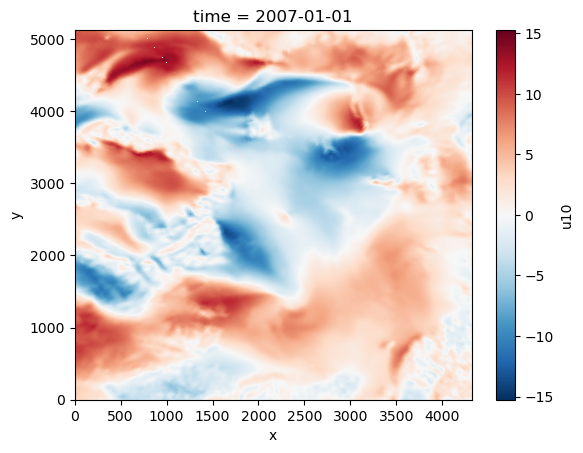

In [49]:
uForcing.isel(time=0).plot()

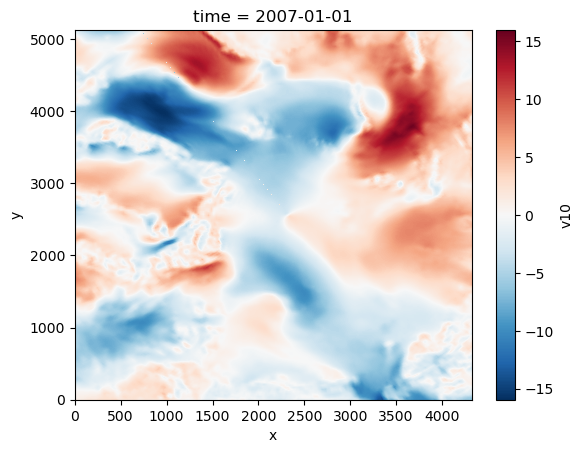

In [50]:
vForcing.isel(time=0).plot()

cubic 2D is not implemented so we have to first do east-west and then north-south